In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import duckdb
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv(r"C:\Users\Rasik\Documents\Phones\Phones.csv")
df.describe()

,fab,size,curved_display,refresh_rate,hbm,ppi,battery,charging_speed,thickness,weight,...,third_mp,fourth_mp,front,colors,antutu,geekbench_single,geekbench_multiple,wireless_charging,ip_rating,price
count,239.000000,239.000000,239.000000,239.000000,217.000000,239.000000,239.000000,239.000000,239.000000,239.000000,...,170.000000,6.000000,239.000000,239.000000,2.390000e+02,239.000000,239.000000,239.000000,239.000000,239.000000
mean,4.192469,6.679833,0.213389,122.937238,1362.926267,412.288703,5887.071130,61.769874,8.058536,197.606695,...,25.881176,20.666667,24.516736,2.962343,1.319833e+06,1585.828452,4647.953975,0.255230,64.451883,43693.723849
std,1.014902,0.169046,0.410560,15.462894,425.453281,63.421065,1143.403033,30.023124,0.545799,15.287858,...,40.144830,23.001449,14.726275,0.997183,9.223469e+05,878.590568,2734.456559,0.436905,7.494871,33112.565882
min,2.000000,6.100000,0.000000,60.000000,450.000000,254.000000,3036.000000,15.000000,5.600000,156.000000,...,2.000000,2.000000,5.000000,2.000000,3.411050e+05,407.000000,1307.000000,0.000000,9.000000,9000.000000
25%,4.000000,6.670000,0.000000,120.000000,1050.000000,388.000000,5000.000000,33.000000,7.800000,187.000000,...,2.000000,4.000000,12.000000,2.000000,6.463175e+05,999.500000,2727.000000,0.000000,64.000000,22000.000000
50%,4.000000,6.720000,0.000000,120.000000,1400.000000,440.000000,6000.000000,50.000000,8.100000,197.000000,...,2.000000,10.000000,18.000000,3.000000,8.925000e+05,1158.000000,3220.000000,0.000000,68.000000,32000.000000
75%,4.000000,6.780000,0.000000,120.000000,1600.000000,453.000000,6710.000000,90.000000,8.400000,208.500000,...,50.000000,40.000000,32.000000,3.000000,1.854940e+06,2077.000000,6563.000000,1.000000,69.000000,55000.000000
max,6.000000,6.900000,1.000000,165.000000,3600.000000,516.000000,10001.000000,125.000000,9.200000,237.000000,...,200.000000,50.000000,50.000000,7.000000,4.110112e+06,3895.000000,11566.000000,1.000000,69.000000,170000.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 42 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  239 non-null    object 
 1   brand                 239 non-null    object 
 2   sale                  239 non-null    object 
 3   processor_type        239 non-null    object 
 4   processor             239 non-null    object 
 5   fab                   239 non-null    int64  
 6   ram_type              239 non-null    object 
 7   rom_type              239 non-null    object 
 8   display_type          239 non-null    object 
 9   size                  239 non-null    float64
 10  curved_display        239 non-null    int64  
 11  refresh_rate          239 non-null    int64  
 12  hbm                   217 non-null    float64
 13  protection            186 non-null    object 
 14  ppi                   239 non-null    int64  
 15  battery               2

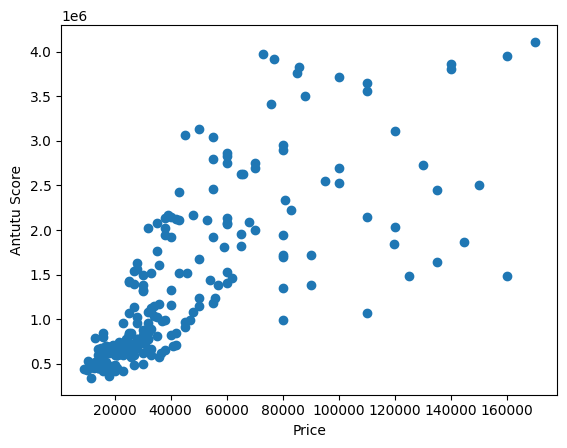

In [4]:
#Visualisation

plt.xlabel("Price")
plt.ylabel("Antutu Score")
plt.scatter(df.price, df.antutu)
plt.show()


In [5]:
from sklearn.preprocessing import OrdinalEncoder
# ENCODING

# 1. RAM & ROM Encoding 
encoder = OrdinalEncoder(categories=[
    ['LPDDR4X', 'LPDDR5', 'LPDDR5X'],        # ram_type
    ['UFS 2.2', 'UFS 3.1', 'NVMe', 'UFS 4.0', 'UFS 4.1']  # rom_type
])

encoded = encoder.fit_transform(df[['ram_type', 'rom_type']])

df['ram_type_encoded'] = encoded[:, 0].astype(int) + 1
df['rom_type_encoded'] = encoded[:, 1].astype(int) + 1

# 2. Sale channel (manual mapping)
sale_map = {'Online': 1, 'Both': 2, 'Offline': 3, 'Flagship': 4}
df['sale_encoded'] = df['sale'].map(sale_map).fillna(0).astype(int)  # 0 = unknown

# 3. Display type (manual mapping)
display_map = {'IPS LCD': 0, 'Amoled': 1}
df['display_type_encoded'] = df['display_type'].map(display_map).fillna(0).astype(int)

# 4. Back material (plastic & leather = 1, others = 2)
back_map = {'Plastic': 1, 'Leather': 1}
df['back_material_encoded'] = df['back_material'].map(back_map).fillna(2).astype(int)

# 5. Frame material (plastic = 1, others = 2)
frame_map = {'Plastic': 1}
df['frame_material_encoded'] = df['frame_material'].map(frame_map).fillna(2).astype(int)

# 6. Speaker type 
speaker_map = {'Mono': 0, 'Stereo': 1}
df['speaker_encoded'] = df['speaker'].map(speaker_map).fillna(0).astype(int)

# 7. Brand (Target encoding) → mean price per brand
brand_price_map = df.groupby('brand')['price'].mean().to_dict()
df['brand_encoded'] = df['brand'].map(brand_price_map)

# 8. Launch date → days since launch 
df['launch_date'] = pd.to_datetime(df['launch_date'], format="%d-%m-%Y", errors='coerce')
df['days_since_launch'] = (pd.to_datetime("today").normalize() - df['launch_date']).dt.days

In [6]:
df.head()

,name,brand,sale,processor_type,processor,fab,ram_type,rom_type,display_type,size,...,price,ram_type_encoded,rom_type_encoded,sale_encoded,display_type_encoded,back_material_encoded,frame_material_encoded,speaker_encoded,brand_encoded,days_since_launch
0,CMF Phone 1,Nothing,Online,Mediatek,Dimensity 7300,4,LPDDR4X,UFS 2.2,Amoled,6.67,...,16000,1,1,1,1,1,1,0,35230.769231,733
1,CMF Phone 2 Pro,Nothing,Online,Mediatek,Dimensity 7300,4,LPDDR4X,UFS 2.2,Amoled,6.77,...,19000,1,1,1,1,1,1,0,35230.769231,409
2,Galaxy A07,Samsung,Offline,Mediatek,Dimensity 6300,6,LPDDR4X,UFS 2.2,IPS LCD,6.70,...,16000,1,1,3,0,1,1,0,52203.703704,156
3,Galaxy A17,Samsung,Offline,Exynos,1330,5,LPDDR4X,UFS 2.2,Amoled,6.70,...,19000,1,1,3,1,1,1,0,52203.703704,316
4,Galaxy A27,Samsung,Offline,Snapdragon,6 Gen 3,4,LPDDR5X,UFS 3.1,Amoled,6.70,...,32000,3,2,3,1,2,1,0,52203.703704,16


In [7]:
con = duckdb.connect()
con.register("phones", df)

In [8]:
query = """
SELECT *
FROM phones
WHERE days_since_launch<=365
"""

data = con.execute(query).df()

data

,name,brand,sale,processor_type,processor,fab,ram_type,rom_type,display_type,size,...,price,ram_type_encoded,rom_type_encoded,sale_encoded,display_type_encoded,back_material_encoded,frame_material_encoded,speaker_encoded,brand_encoded,days_since_launch
0,Galaxy A07,Samsung,Offline,Mediatek,Dimensity 6300,6,LPDDR4X,UFS 2.2,IPS LCD,6.70,...,16000,1,1,3,0,1,1,0,52203.703704,156
1,Galaxy A17,Samsung,Offline,Exynos,1330,5,LPDDR4X,UFS 2.2,Amoled,6.70,...,19000,1,1,3,1,1,1,0,52203.703704,316
2,Galaxy A27,Samsung,Offline,Snapdragon,6 Gen 3,4,LPDDR5X,UFS 3.1,Amoled,6.70,...,32000,3,2,3,1,2,1,0,52203.703704,16
3,Galaxy A37,Samsung,Offline,Exynos,1480,4,LPDDR5X,UFS 3.1,Amoled,6.70,...,42000,3,2,3,1,2,1,1,52203.703704,108
4,Galaxy A57,Samsung,Offline,Exynos,1680,4,LPDDR5X,UFS 3.1,Amoled,6.70,...,57000,3,2,3,1,2,2,1,52203.703704,108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,Xiaomi 17,Xiaomi,Flagship,Snapdragon,8 Elite Gen 5,3,LPDDR5X,UFS 4.1,Amoled,6.30,...,100000,3,5,4,1,2,2,1,34714.285714,122
128,Xiaomi 17 Ultra,Xiaomi,Flagship,Snapdragon,8 Elite Gen 5,3,LPDDR5X,UFS 4.1,Amoled,6.90,...,140000,3,5,4,1,2,2,1,34714.285714,121
129,Xiaomi 17T,Xiaomi,Both,Mediatek,Dimensity 8500,4,LPDDR5X,UFS 4.1,Amoled,6.59,...,60000,3,5,2,1,1,1,1,34714.285714,37
130,Nothing Phone 4b,Nothing,Both,Snapdragon,6 Gen 4,4,LPDDR4X,UFS 2.2,Amoled,6.77,...,35000,1,1,2,1,1,1,1,35230.769231,4


In [9]:
# Regression for Antutu Score

linear = LinearRegression()
X = data[['fab','days_since_launch','ram_type_encoded','rom_type_encoded','size','thickness','geekbench_single','geekbench_multiple']]
y = data['antutu']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
linear.fit(X_train, y_train)
y_pred = linear.predict(X_test)

In [11]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Squared Error (MSE): 38013717611.30
Root Mean Squared Error (RMSE): 194971.07
Mean Absolute Error (MAE): 157413.07
R-squared (R2): 0.96


In [12]:
feature_names = X_train.columns.tolist()
coef = linear.coef_
intercept = linear.intercept_

import pandas as pd
weights_df = pd.DataFrame({"feature": feature_names, "weight": coef}) \
                .sort_values(by="weight", key=lambda s: s.abs(), ascending=False)

print("\nIntercept (bias):", intercept)
print("\nFeature weights (sorted by absolute value):")
print(weights_df.to_string(index=False))


Intercept (bias): -3495695.2703960286

Feature weights (sorted by absolute value):
           feature        weight
              size 430214.259095
  rom_type_encoded 141715.418888
  ram_type_encoded -46114.895607
         thickness  38827.015618
               fab  35338.737509
 days_since_launch   -544.878212
geekbench_multiple    372.414041
  geekbench_single   -206.510908


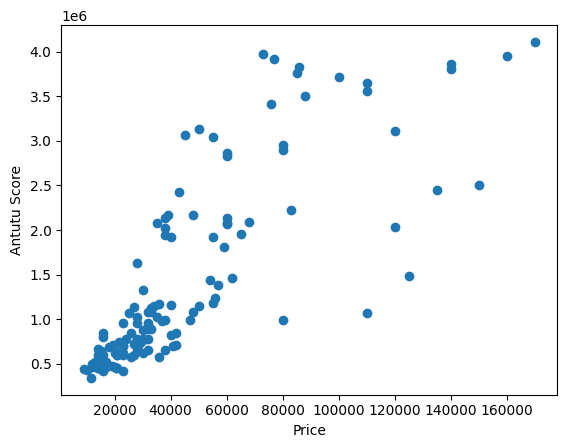

In [13]:
plt.xlabel("Price")
plt.ylabel("Antutu Score")
plt.scatter(data.price, data.antutu)
plt.show()

In [14]:
new_data = [[4, 0, 3, 5, 6.6, 8, 1973, 4863]]
prediction = linear.predict(new_data)

print(prediction)

[1769525.78351369]


C:\Users\Rasik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
# Regression for Price

linear = LinearRegression()
X = data[['brand','days_since_launch','sale_encoded','size','display_type_encoded','refresh_rate','ppi','battery','charging_speed',
          'antutu','ram_type_encoded','rom_type_encoded','back_material_encoded','frame_material_encoded','useful_camera_number','speaker_encoded',
          'wireless_charging','ip_rating']]
y = data['price']

brand_map = data.groupby('brand')['price'].mean()
global_mean = data['price'].mean()

X = X.copy()
X['brand'] = X['brand'].map(brand_map).fillna(global_mean)

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=42)


In [16]:
linear = LinearRegression()

linear.fit(X_train, np.log1p(y_train))

y_pred_log = linear.predict(X_test)
y_pred = np.expm1(y_pred_log)

In [23]:
new_data = [['Vivo',0,3,6.6,1,120,460,7200,90,1458473,3,5,2,2,3,1,0,69]]
new_data[0][0] = brand_map.get(new_data[0][0], global_mean)
prediction = linear.predict(new_data)
prediction = np.expm1(prediction)
prediction = round(prediction[0] / 1000) * 1000 - 1

print(prediction)

65999


C:\Users\Rasik\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


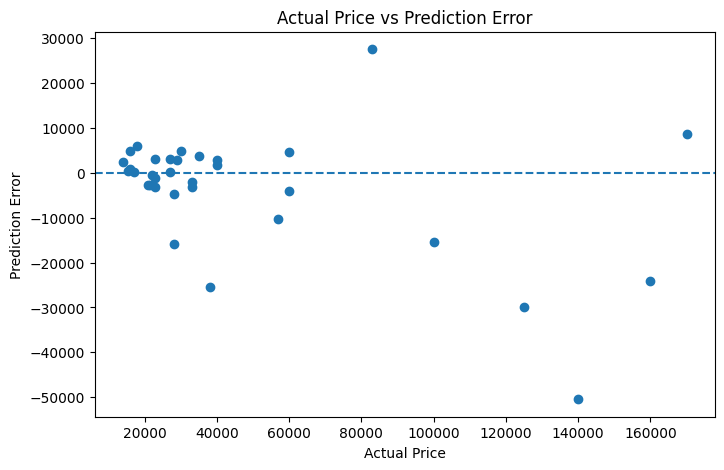

In [18]:
error = y_pred - y_test

plt.figure(figsize=(8,5))
plt.scatter(y_test, error)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Prediction Error")
plt.title("Actual Price vs Prediction Error")
plt.show()

In [19]:
# Error
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.893191391868613
MAE: 8292.547867324001
RMSE: 13869.454344249207


In [20]:
# 1. Summary for numerical columns
print("\n📊 Numerical Feature Summary:")
print(data.describe())

# 2. Summary for categorical columns
print("\n🔤 Categorical Feature Distribution:")
categorical_cols = data.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(data[col].value_counts(dropna=False))  # dropna=False to include NaNs

# 3. Optional: check missing values
print("\n❓ Missing Values per Column:")
print(data.isnull().sum())


📊 Numerical Feature Summary:
              fab       size  curved_display  refresh_rate          hbm  \
count  132.000000  132.00000      132.000000    132.000000   119.000000   
mean     4.272727    6.69197        0.174242    125.500000  1418.697479   
min      2.000000    6.10000        0.000000     60.000000   450.000000   
25%      4.000000    6.60000        0.000000    120.000000  1050.000000   
50%      4.000000    6.75500        0.000000    120.000000  1500.000000   
75%      5.000000    6.80000        0.000000    126.000000  1800.000000   
max      6.000000    6.90000        1.000000    165.000000  3600.000000   
std      1.098861    0.16657        0.380763     14.385903   482.964215   

              ppi       battery  charging_speed   thickness      weight  ...  \
count  132.000000    132.000000      132.000000  132.000000  132.000000  ...   
mean   404.704545   6317.621212       60.037879    8.018333  200.166667  ...   
min    254.000000   3036.000000       15.000000    5.6

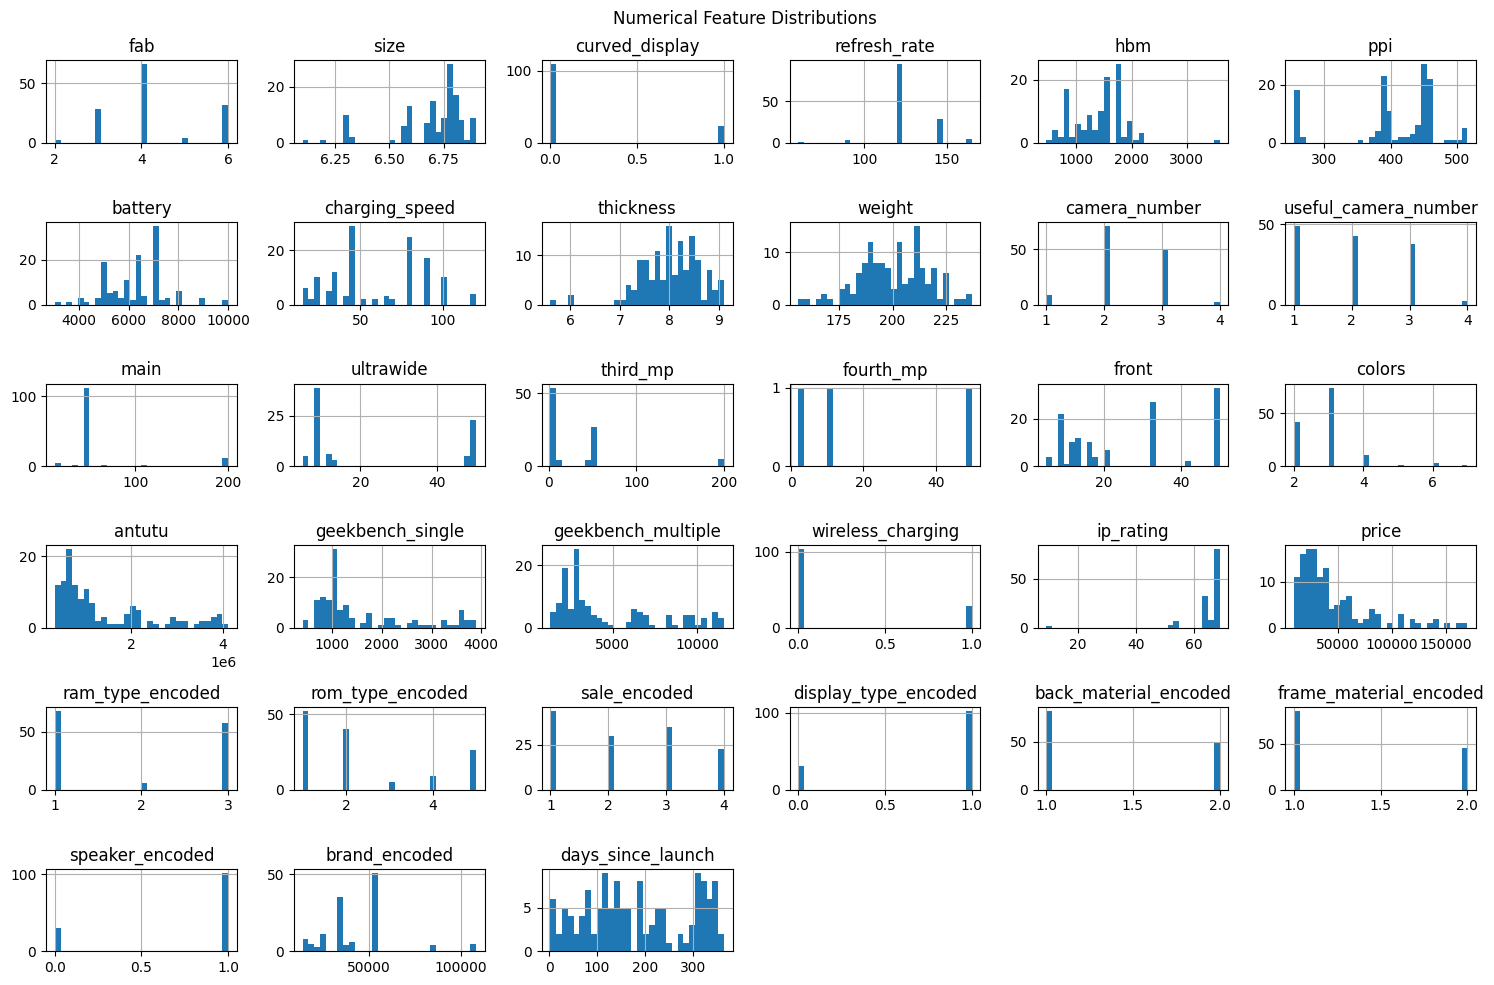

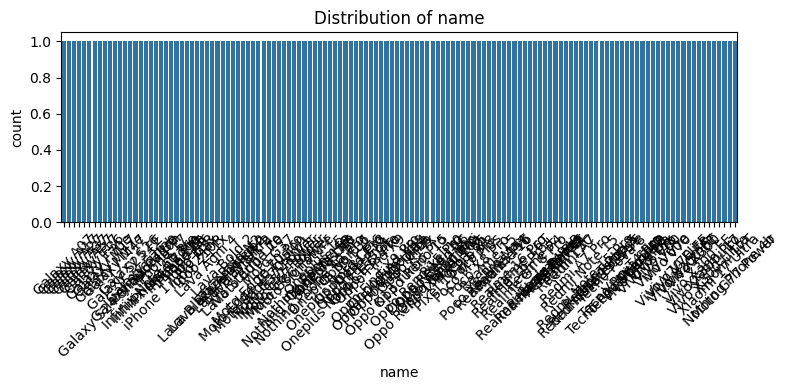

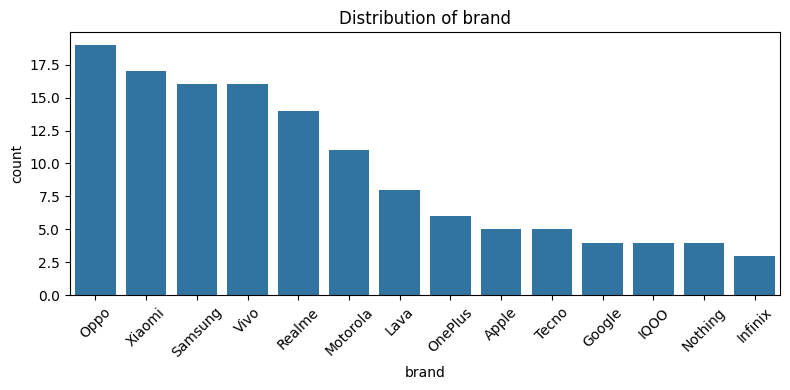

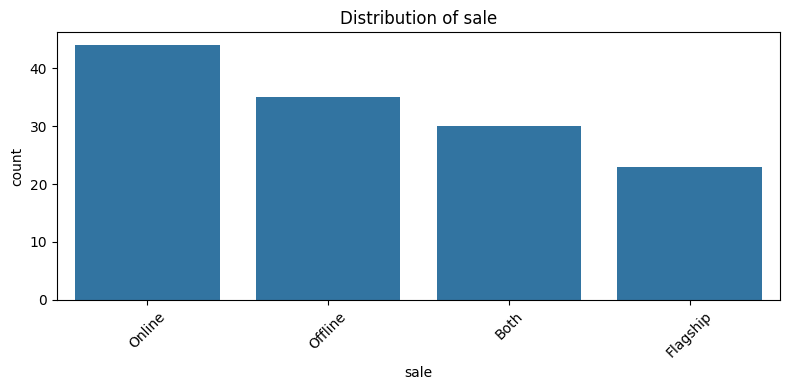

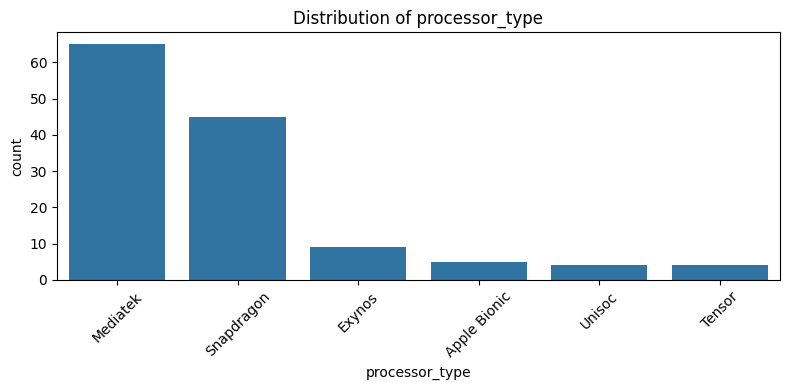

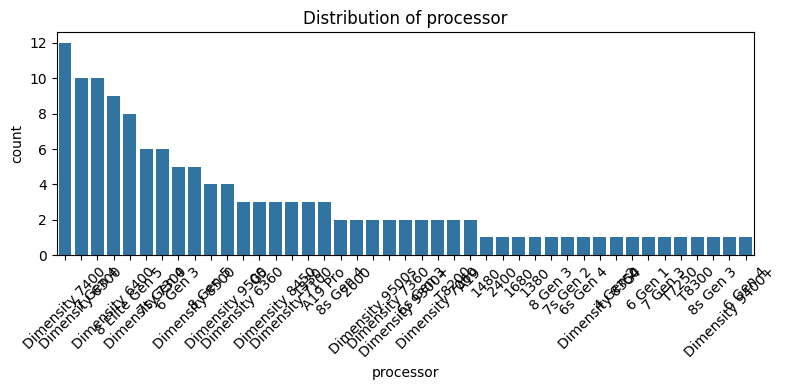

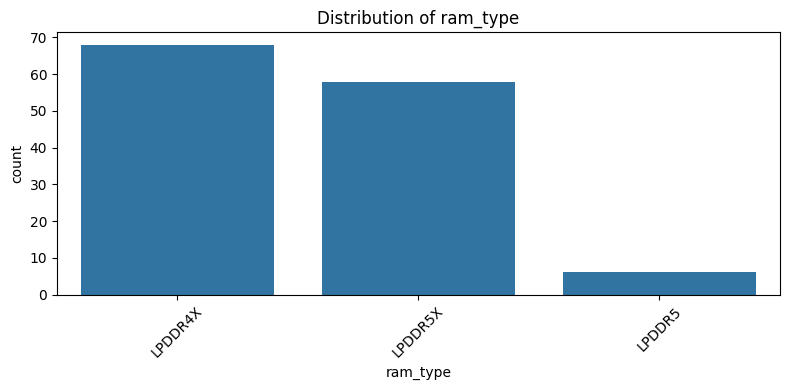

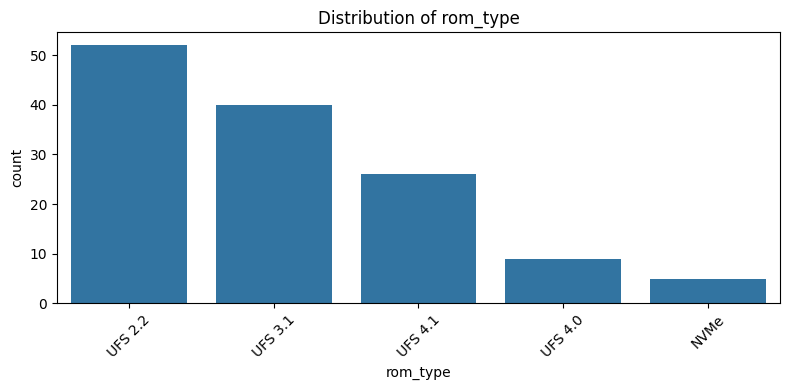

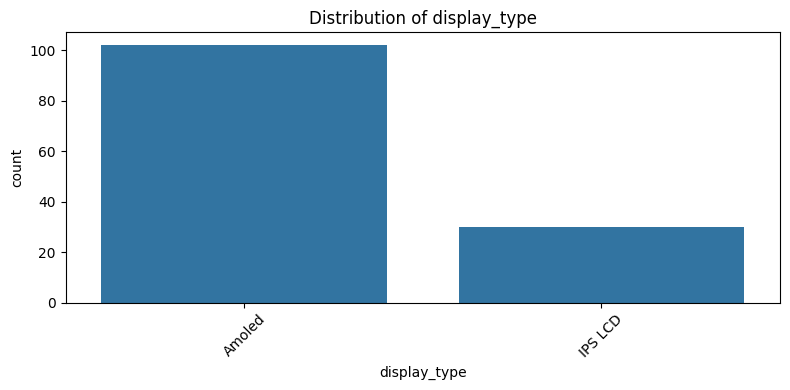

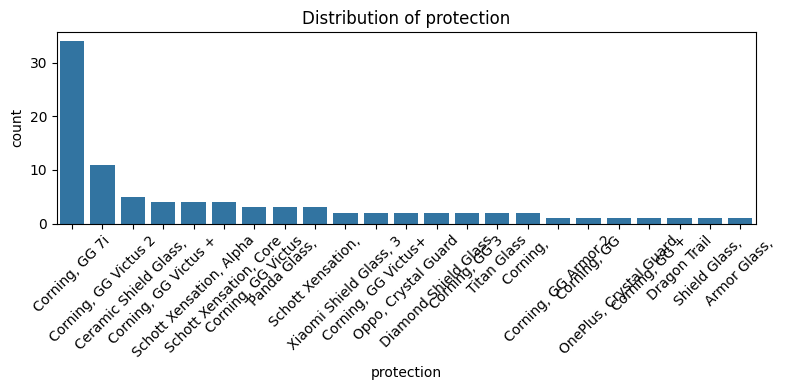

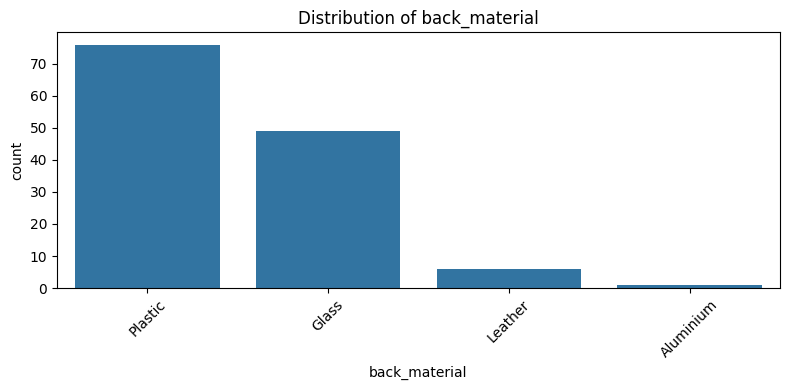

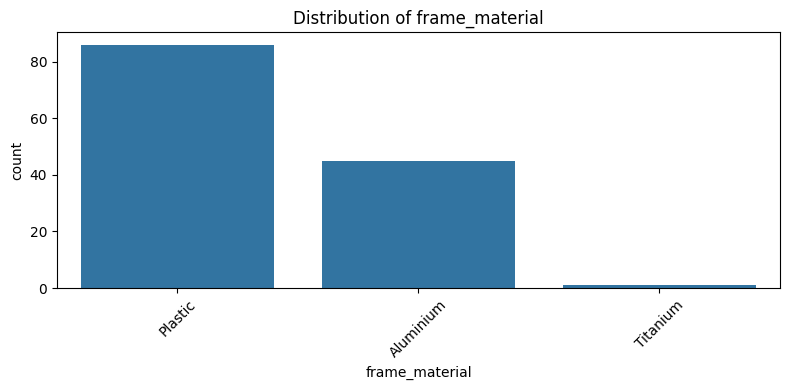

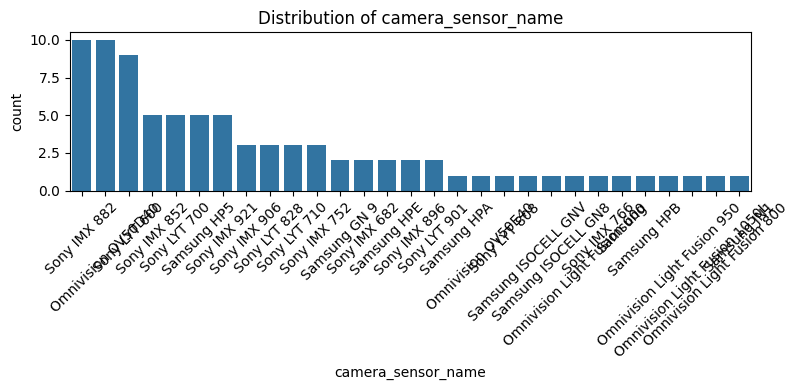

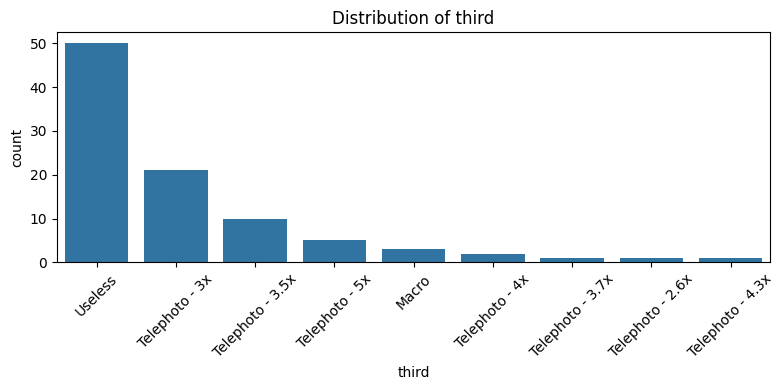

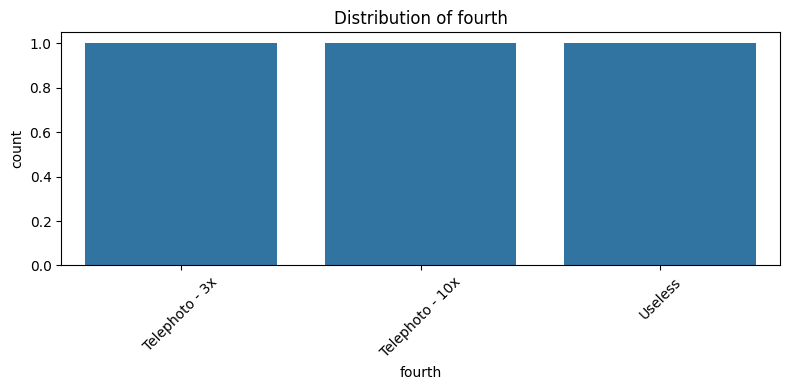

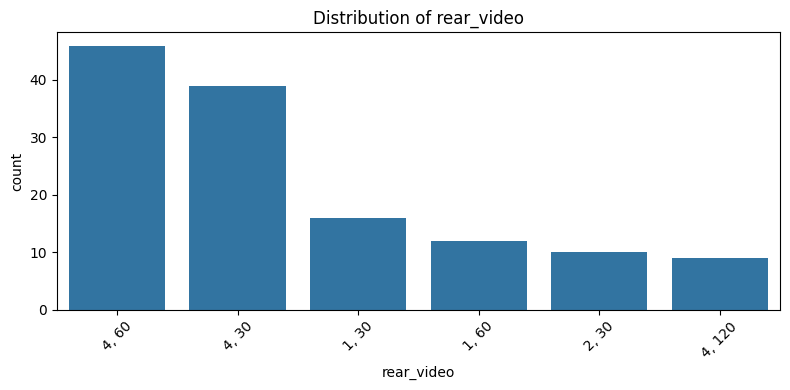

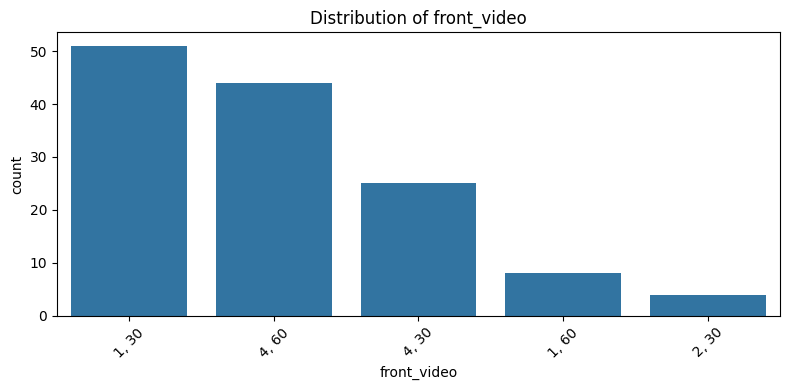

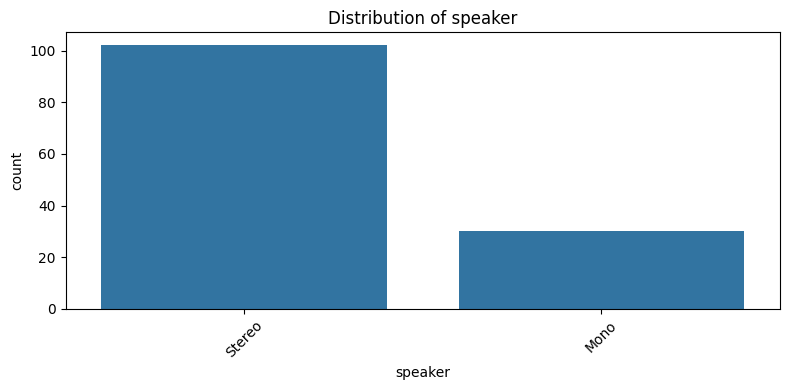

In [21]:
# Histograms for numeric features
data.select_dtypes(include='number').hist(figsize=(15, 10), bins=30)
plt.suptitle("Numerical Feature Distributions")
plt.tight_layout()
plt.show()

# Count plots for categorical features
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=data, x=col, order=data[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [22]:
query = """
SELECT AVG(main) AS mp
FROM phones
"""

data = con.execute(query).df()

data

,mp
0,61.062762
